In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [4]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

DATASET OVERVIEW
Shape       : (8807, 12)
Columns     : ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

df_clean = df.copy()

# Fill missing values
df_clean['director']    = df_clean['director'].fillna('Unknown Director')
df_clean['cast']        = df_clean['cast'].fillna('Unknown Cast')
df_clean['country']     = df_clean['country'].fillna('Unknown Country')
df_clean['rating']      = df_clean['rating'].fillna(df_clean['rating'].mode()[0])
df_clean['date_added']  = df_clean['date_added'].fillna('Unknown Date')
df_clean['duration']    = df_clean['duration'].fillna('Unknown')
df_clean['listed_in']   = df_clean['listed_in'].fillna('Unknown Genre')
df_clean['description'] = df_clean['description'].fillna('')

# Remove duplicates
before = len(df_clean)
df_clean.drop_duplicates(subset='title', keep='first', inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"Removed {before - len(df_clean)} duplicate titles. Rows remaining: {len(df_clean)}")

# Parse date_added → year
df_clean['year_added'] = pd.to_datetime(
    df_clean['date_added'].str.strip(), errors='coerce'
).dt.year.fillna(0).astype(int)

# Parse duration_mins (Movies) and duration_seasons (TV Shows)
df_clean['duration_mins'] = df_clean.apply(
    lambda r: int(r['duration'].split()[0]) if 'min' in str(r['duration']) else 0, axis=1
)
df_clean['duration_seasons'] = df_clean.apply(
    lambda r: int(r['duration'].split()[0]) if 'Season' in str(r['duration']) else 0, axis=1
)

print(f"Missing values after cleaning:\n{df_clean.isnull().sum()}")


DATA CLEANING
Removed 0 duplicate titles. Rows remaining: 8807
Missing values after cleaning:
show_id             0
type                0
title               0
director            0
cast                0
country             0
date_added          0
release_year        0
rating              0
duration            0
listed_in           0
description         0
year_added          0
duration_mins       0
duration_seasons    0
dtype: int64


In [6]:
print("\n" + "=" * 60)
print("TYPE CONVERSION")
print("=" * 60)

le_type   = LabelEncoder()
le_rating = LabelEncoder()

df_clean['type_encoded']   = le_type.fit_transform(df_clean['type'])
df_clean['rating_encoded'] = le_rating.fit_transform(df_clean['rating'])

# Multi-label binarizer for genres
df_clean['genres_list'] = df_clean['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')])
mlb = MultiLabelBinarizer()
genres_df = pd.DataFrame(
    mlb.fit_transform(df_clean['genres_list']),
    columns=mlb.classes_,
    index=df_clean.index
)

print(f"type_encoded   : {dict(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")
print(f"rating classes : {list(le_rating.classes_)}")
print(f"Genre columns  : {list(mlb.classes_)}")


TYPE CONVERSION
type_encoded   : {'Movie': np.int64(0), 'TV Show': np.int64(1)}
rating classes : ['66 min', '74 min', '84 min', 'G', 'NC-17', 'NR', 'PG', 'PG-13', 'R', 'TV-14', 'TV-G', 'TV-MA', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']
Genre columns  : ['Action & Adventure', 'Anime Features', 'Anime Series', 'British TV Shows', 'Children & Family Movies', 'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows', 'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas', 'Faith & Spirituality', 'Horror Movies', 'Independent Movies', 'International Movies', 'International TV Shows', "Kids' TV", 'Korean TV Shows', 'LGBTQ Movies', 'Movies', 'Music & Musicals', 'Reality TV', 'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy', 'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows', 'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror', 'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Shows', 'TV Thrillers


DATA VISUALIZATION


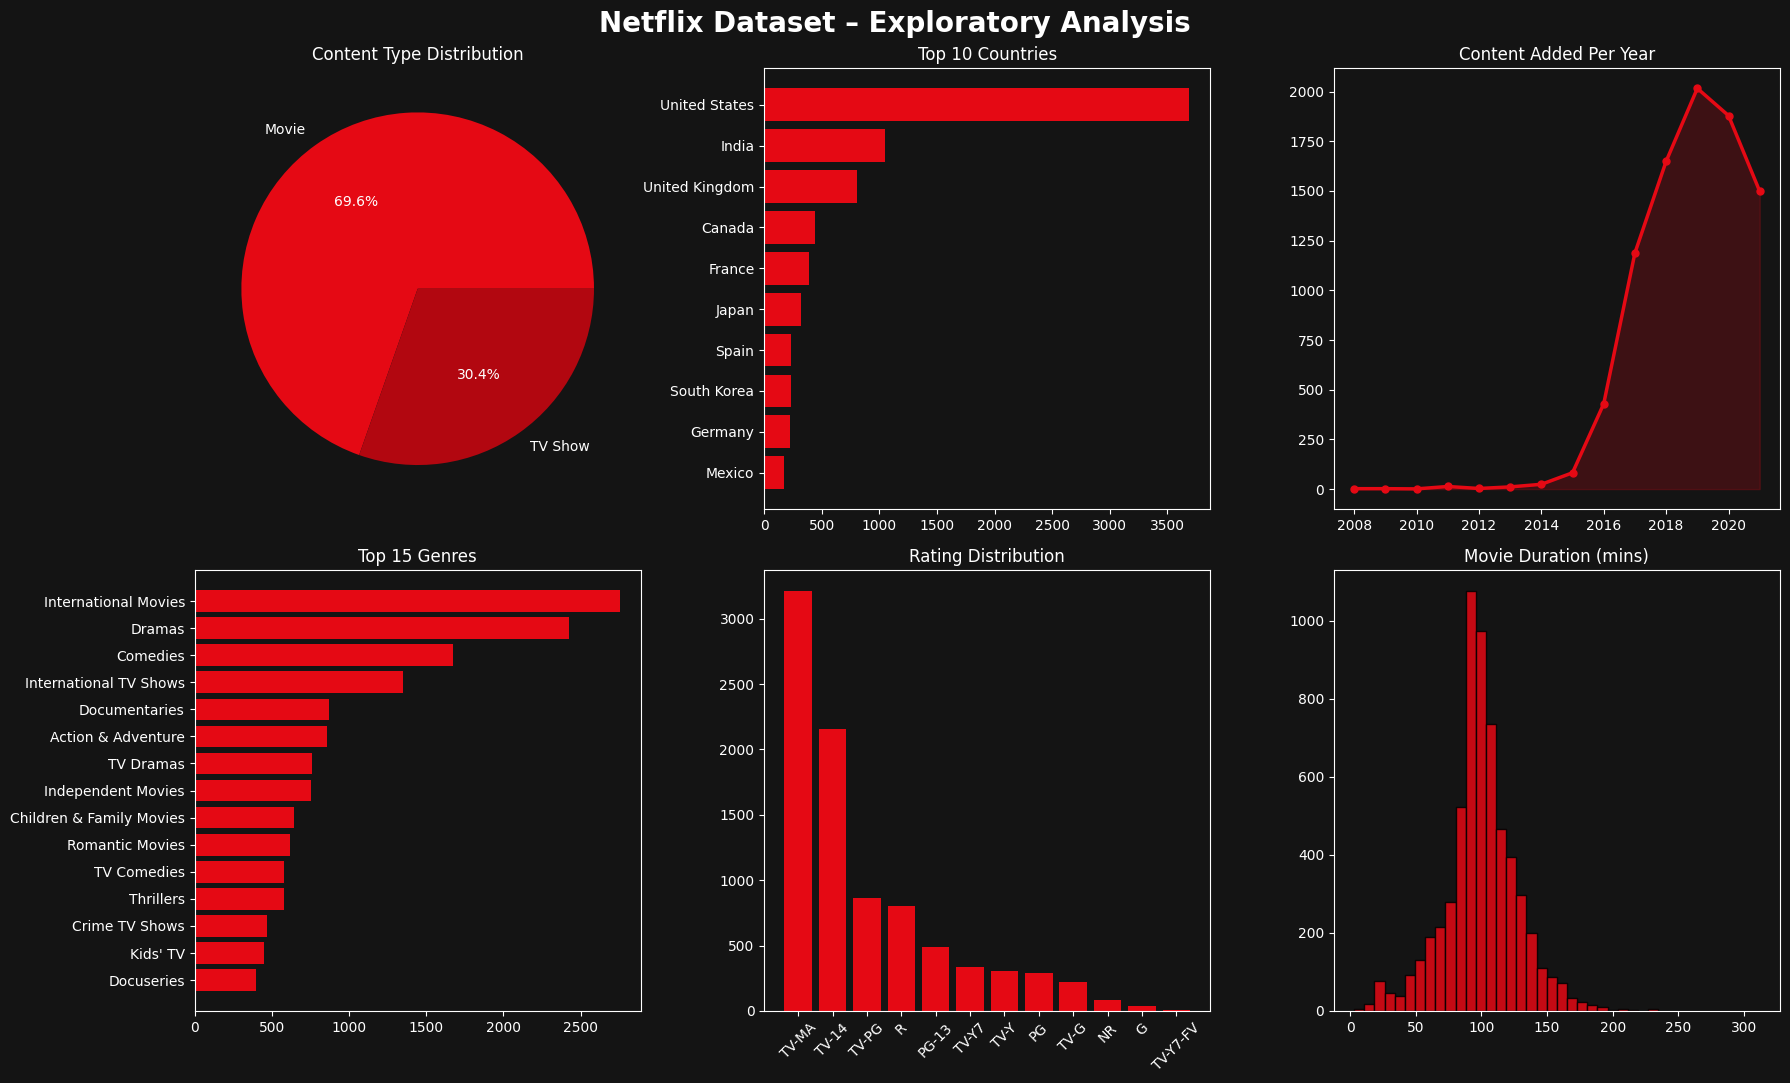

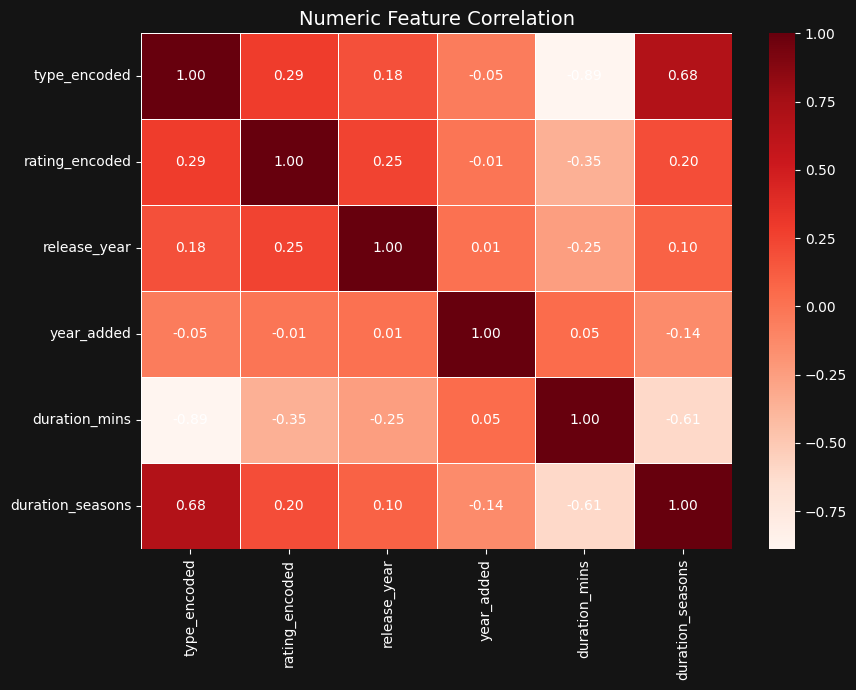

In [11]:
print("\n" + "=" * 60)
print("DATA VISUALIZATION")
print("=" * 60)

plt.style.use('dark_background')
fig_color = '#E50914'   # Netflix red
bg_color  = '#141414'
text_col  = 'white'

# --- Fig 1: Movies vs TV Shows ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor=bg_color)
fig.suptitle('Netflix Dataset – Exploratory Analysis', fontsize=20, color=text_col, fontweight='bold')

type_counts = df_clean['type'].value_counts()
axes[0, 0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
               colors=[fig_color, '#B20710'], textprops={'color': text_col})
axes[0, 0].set_title('Content Type Distribution', color=text_col)

# --- Fig 2: Top 10 Countries ---
top_countries = df_clean['country'].str.split(',').explode().str.strip()
top_countries = top_countries[top_countries != 'Unknown Country'].value_counts().head(10)
axes[0, 1].barh(top_countries.index[::-1], top_countries.values[::-1], color=fig_color)
axes[0, 1].set_title('Top 10 Countries', color=text_col)
axes[0, 1].tick_params(colors=text_col)
axes[0, 1].set_facecolor(bg_color)

# --- Fig 3: Content Added Per Year ---
yearly = df_clean[df_clean['year_added'] > 2000]['year_added'].value_counts().sort_index()
axes[0, 2].plot(yearly.index, yearly.values, color=fig_color, linewidth=2.5, marker='o', markersize=5)
axes[0, 2].fill_between(yearly.index, yearly.values, alpha=0.2, color=fig_color)
axes[0, 2].set_title('Content Added Per Year', color=text_col)
axes[0, 2].tick_params(colors=text_col)
axes[0, 2].set_facecolor(bg_color)

# --- Fig 4: Top 15 Genres ---
all_genres = df_clean['listed_in'].str.split(',').explode().str.strip().value_counts().head(15)
axes[1, 0].barh(all_genres.index[::-1], all_genres.values[::-1], color=fig_color)
axes[1, 0].set_title('Top 15 Genres', color=text_col)
axes[1, 0].tick_params(colors=text_col)
axes[1, 0].set_facecolor(bg_color)

# --- Fig 5: Rating Distribution ---
rating_counts = df_clean['rating'].value_counts().head(12)
axes[1, 1].bar(rating_counts.index, rating_counts.values, color=fig_color)
axes[1, 1].set_title('Rating Distribution', color=text_col)
axes[1, 1].tick_params(axis='x', rotation=45, colors=text_col)
axes[1, 1].tick_params(axis='y', colors=text_col)
axes[1, 1].set_facecolor(bg_color)

# --- Fig 6: Movie Duration Distribution ---
movies = df_clean[(df_clean['type'] == 'Movie') & (df_clean['duration_mins'] > 0)]
axes[1, 2].hist(movies['duration_mins'], bins=40, color=fig_color, edgecolor='black', alpha=0.85)
axes[1, 2].set_title('Movie Duration (mins)', color=text_col)
axes[1, 2].tick_params(colors=text_col)
axes[1, 2].set_facecolor(bg_color)

plt.tight_layout()

# --- Fig 7: Correlation heatmap of numeric features ---
numeric_cols = ['type_encoded', 'rating_encoded', 'release_year', 'year_added',
                'duration_mins', 'duration_seasons']
corr = df_clean[numeric_cols].corr()

fig2, ax2 = plt.subplots(figsize=(9, 7), facecolor=bg_color)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', ax=ax2,
            linewidths=0.5, annot_kws={'color': text_col})
ax2.set_title('Numeric Feature Correlation', color=text_col, fontsize=14)
ax2.tick_params(colors=text_col)
plt.tight_layout()

In [12]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Build a rich "soup" of text features per title
def build_soup(row):
    genres   = row['listed_in'].replace(',', ' ').replace('&', '')
    director = row['director'].replace(' ', '') if row['director'] != 'Unknown Director' else ''
    cast_top = ' '.join([c.strip().replace(' ', '') for c in row['cast'].split(',')[:4]])
    return f"{genres} {director} {cast_top} {row['type']} {row['description']}"

df_clean['soup'] = df_clean.apply(build_soup, axis=1)
print("Content 'soup' sample:\n", df_clean['soup'].iloc[0][:200])


FEATURE ENGINEERING
Content 'soup' sample:
 Documentaries KirstenJohnson UnknownCast Movie As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.


In [13]:
print("\n--- Model A: TF-IDF Cosine Similarity ---")
tfidf = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df_clean['soup'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


--- Model A: TF-IDF Cosine Similarity ---
TF-IDF matrix shape: (8807, 15000)


In [14]:
# Compute similarity on the full matrix
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print("Cosine similarity matrix computed.")

Cosine similarity matrix computed.


In [15]:
print("\n--- Model B: KNN Recommender ---")
knn_model = NearestNeighbors(n_neighbors=11, metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)
print("KNN model fitted.")


--- Model B: KNN Recommender ---
KNN model fitted.


In [16]:
print("\n--- Model C: TruncatedSVD Latent Factor ---")
svd = TruncatedSVD(n_components=100, random_state=42)
latent_matrix = svd.fit_transform(tfidf_matrix)
print(f"Latent matrix shape: {latent_matrix.shape}")
print(f"Explained variance ratio (total): {svd.explained_variance_ratio_.sum():.4f}")


--- Model C: TruncatedSVD Latent Factor ---
Latent matrix shape: (8807, 100)
Explained variance ratio (total): 0.1565



MODEL EVALUATION
Precision@10 — TF-IDF Cosine : 0.8200
Precision@10 — KNN           : 0.8200
Precision@10 — SVD           : 0.9500

✅  BEST MODEL: SVD  (Precision@10 = 0.9500)


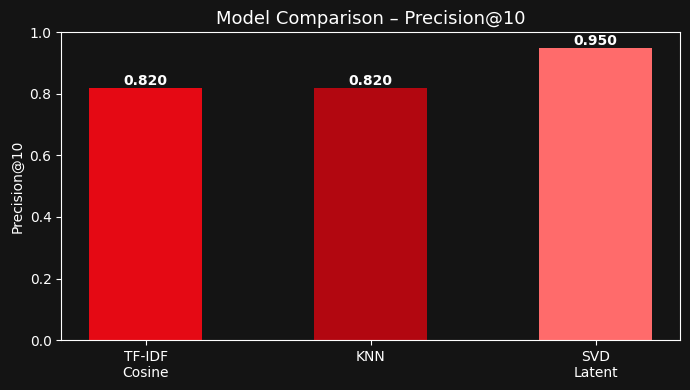

In [17]:
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

def precision_at_k(recommendations, query_genres, k=10):
    """Fraction of top-k recs sharing ≥1 genre with the query."""
    hits = sum(
        1 for _, row in recommendations.head(k).iterrows()
        if any(g in row['listed_in'] for g in query_genres)
    )
    return hits / k

# Quick benchmark on 50 random titles
sample_idx = np.random.choice(len(df_clean), 50, replace=False)
scores_cosine, scores_knn, scores_svd = [], [], []

indices_map = pd.Series(df_clean.index, index=df_clean['title']).drop_duplicates()

for idx in sample_idx:
    row     = df_clean.iloc[idx]
    qgenres = [g.strip() for g in row['listed_in'].split(',')]

    # Cosine
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:11]
    recs_cos   = df_clean.iloc[[i for i, _ in sim_scores]]
    scores_cosine.append(precision_at_k(recs_cos, qgenres))

    # KNN
    distances, neighbor_idx = knn_model.kneighbors(tfidf_matrix[idx], n_neighbors=11)
    recs_knn = df_clean.iloc[neighbor_idx[0][1:]]
    scores_knn.append(precision_at_k(recs_knn, qgenres))

    # SVD cosine
    vec    = latent_matrix[idx].reshape(1, -1)
    sims   = cosine_similarity(vec, latent_matrix)[0]
    top_idx = np.argsort(sims)[::-1][1:11]
    recs_svd = df_clean.iloc[top_idx]
    scores_svd.append(precision_at_k(recs_svd, qgenres))

print(f"Precision@10 — TF-IDF Cosine : {np.mean(scores_cosine):.4f}")
print(f"Precision@10 — KNN           : {np.mean(scores_knn):.4f}")
print(f"Precision@10 — SVD           : {np.mean(scores_svd):.4f}")

best_model = max(
    [('TF-IDF Cosine', np.mean(scores_cosine)),
     ('KNN',           np.mean(scores_knn)),
     ('SVD',           np.mean(scores_svd))],
    key=lambda x: x[1]
)
print(f"\n✅  BEST MODEL: {best_model[0]}  (Precision@10 = {best_model[1]:.4f})")

# Plot comparison
fig3, ax3 = plt.subplots(figsize=(7, 4), facecolor=bg_color)
model_names  = ['TF-IDF\nCosine', 'KNN', 'SVD\nLatent']
model_scores = [np.mean(scores_cosine), np.mean(scores_knn), np.mean(scores_svd)]
bars = ax3.bar(model_names, model_scores, color=[fig_color, '#B20710', '#FF6B6B'], width=0.5)
ax3.set_ylim(0, 1)
ax3.set_ylabel('Precision@10', color=text_col)
ax3.set_title('Model Comparison – Precision@10', color=text_col, fontsize=13)
ax3.tick_params(colors=text_col)
ax3.set_facecolor(bg_color)
for bar, score in zip(bars, model_scores):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', color=text_col, fontweight='bold')
plt.tight_layout()

In [18]:
def get_recommendations_by_title(title, n=10):
    """
    Recommend n titles similar to the given title.
    Uses: TF-IDF Cosine Similarity (best model)
    """
    title_clean = title.strip().lower()
    matches = df_clean[df_clean['title'].str.lower() == title_clean]

    if matches.empty:
        # Fuzzy fallback: partial match
        matches = df_clean[df_clean['title'].str.lower().str.contains(title_clean, na=False)]
        if matches.empty:
            return f"❌  Title '{title}' not found. Try a different name."
        print(f"  (Exact match not found; using closest: '{matches.iloc[0]['title']}')")

    idx       = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]
    rec_idx    = [i for i, _ in sim_scores]

    result = df_clean.iloc[rec_idx][['title', 'type', 'listed_in', 'rating',
                                     'release_year', 'description']].copy()
    result['similarity_score'] = [round(s, 4) for _, s in sim_scores]
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    return result


def get_recommendations_by_genre(genre, content_type=None, n=10):
    """
    Recommend titles from a specific genre.
    Optionally filter by content_type: 'Movie' or 'TV Show'
    """
    filtered = df_clean[df_clean['listed_in'].str.contains(genre, case=False, na=False)]
    if content_type:
        filtered = filtered[filtered['type'] == content_type]
    if filtered.empty:
        return f"❌  No titles found for genre '{genre}'."

    # Pick a seed from filtered, return neighbours
    seed_idx  = filtered.index[0]
    sim_scores = list(enumerate(cosine_sim[seed_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Keep only rows that match the genre filter
    result_rows = []
    for i, score in sim_scores:
        row = df_clean.iloc[i]
        if genre.lower() in row['listed_in'].lower():
            result_rows.append((i, score))
        if len(result_rows) == n:
            break

    result = df_clean.iloc[[i for i, _ in result_rows]][
        ['title', 'type', 'listed_in', 'rating', 'release_year', 'description']].copy()
    result['similarity_score'] = [round(s, 4) for _, s in result_rows]
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    return result


def get_recommendations_by_description(user_text, n=10):
    """
    Recommend titles based on a free-text description provided by the user.
    """
    user_vec   = tfidf.transform([user_text])
    sim_scores = cosine_similarity(user_vec, tfidf_matrix)[0]
    top_idx    = np.argsort(sim_scores)[::-1][:n]

    result = df_clean.iloc[top_idx][['title', 'type', 'listed_in', 'rating',
                                     'release_year', 'description']].copy()
    result['similarity_score'] = np.round(sim_scores[top_idx], 4)
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    return result

In [19]:
def display_recommendations(recs, query_label):
    if isinstance(recs, str):
        print(recs)
        return
    print(f"\n{'─'*70}")
    print(f"  🎬  Top Recommendations for: {query_label}")
    print(f"{'─'*70}")
    for i, row in recs.iterrows():
        print(f"  {i:>2}. [{row['type']}]  {row['title']}  ({row['release_year']})")
        print(f"      Genre  : {row['listed_in']}")
        print(f"      Rating : {row['rating']}   |  Similarity: {row['similarity_score']}")
        print(f"      {row['description'][:110]}...")
        print()


def run_recommendation_system():
    """Interactive CLI for the Netflix Recommendation System."""
    print("\n" + "=" * 70)
    print("   🍿  NETFLIX RECOMMENDATION SYSTEM  🍿")
    print("=" * 70)
    print("  Mode 1 : Recommend by Title")
    print("  Mode 2 : Recommend by Genre")
    print("  Mode 3 : Recommend by Description / Mood")
    print("  Mode 4 : Quick Demo (auto-run examples)")
    print("  quit   : Exit")
    print("=" * 70)

    while True:
        mode = input("\nEnter mode (1 / 2 / 3 / 4 / quit): ").strip().lower()

        if mode == 'quit':
            print("Thanks for using the Netflix Recommender! 🎬")
            break

        elif mode == '1':
            title = input("  Enter a Netflix title: ").strip()
            n     = int(input("  How many recommendations? [default 10]: ").strip() or 10)
            recs  = get_recommendations_by_title(title, n)
            display_recommendations(recs, f'"{title}"')

        elif mode == '2':
            genre = input("  Enter a genre (e.g. Documentaries, Dramas, Comedies): ").strip()
            ctype = input("  Filter by type? (Movie / TV Show / leave blank): ").strip() or None
            n     = int(input("  How many recommendations? [default 10]: ").strip() or 10)
            recs  = get_recommendations_by_genre(genre, ctype, n)
            display_recommendations(recs, f'Genre: {genre}')

        elif mode == '3':
            desc = input("  Describe what you want to watch: ").strip()
            n    = int(input("  How many recommendations? [default 10]: ").strip() or 10)
            recs = get_recommendations_by_description(desc, n)
            display_recommendations(recs, f'Description: "{desc[:50]}..."')

        elif mode == '4':
            # ── Demo examples ──
            print("\n📌  DEMO 1 – Similar to 'Stranger Things'")
            display_recommendations(get_recommendations_by_title('Stranger Things', 5),
                                    'Stranger Things')

            print("\n📌  DEMO 2 – Top Documentaries (Movies only)")
            display_recommendations(get_recommendations_by_genre('Documentaries', 'Movie', 5),
                                    'Documentaries (Movies)')

            print("\n📌  DEMO 3 – Mood: 'crime thriller with suspense and a twist ending'")
            display_recommendations(
                get_recommendations_by_description(
                    'crime thriller with suspense and a twist ending', 5),
                'crime thriller with suspense and a twist ending')

        else:
            print("  ⚠  Invalid choice. Please enter 1, 2, 3, 4, or quit.")

In [21]:
if __name__ == '__main__':
    run_recommendation_system()


   🍿  NETFLIX RECOMMENDATION SYSTEM  🍿
  Mode 1 : Recommend by Title
  Mode 2 : Recommend by Genre
  Mode 3 : Recommend by Description / Mood
  Mode 4 : Quick Demo (auto-run examples)
  quit   : Exit

Enter mode (1 / 2 / 3 / 4 / quit): 2
  Enter a genre (e.g. Documentaries, Dramas, Comedies): Horror Movies
  Filter by type? (Movie / TV Show / leave blank): TV Show
  How many recommendations? [default 10]: 10
❌  No titles found for genre 'Horror Movies'.

Enter mode (1 / 2 / 3 / 4 / quit): 2
  Enter a genre (e.g. Documentaries, Dramas, Comedies): Dramas
  Filter by type? (Movie / TV Show / leave blank): Movie
  How many recommendations? [default 10]: 10

──────────────────────────────────────────────────────────────────────
  🎬  Top Recommendations for: Genre: Dramas
──────────────────────────────────────────────────────────────────────
   1. [Movie]  Sankofa  (1993)
      Genre  : Dramas, Independent Movies, International Movies
      Rating : TV-MA   |  Similarity: 1.0
      On a pho